# Consistent character generation under background switching
## Hyperparameters and environment dependencies
The following parameters are consistent with those in `inference.py`, please refer to the detailed instructions in the `README`.

In [4]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2,4"

In [5]:
init_mode = 2
model_path = "/mnt/netdisk2/zhangyf/model/FLUX.1-dev"
use_interpolate = True
height = 1024
width = 1024
seed = 2025
point_match_save_dir = "/mnt/netdisk2/zhangyf/workspace/CharaConsist/resource/point_pkgs/token_seperate/1203-2"
os.makedirs(point_match_save_dir, exist_ok=True)

import copy
import torch
import numpy as np
from PIL import Image

from models.attention_processor_characonsist import (
    reset_attn_processor,
    set_text_len,
)
from models.pipeline_characonsist import CharaConsistPipeline
from visualize_gr import save_point_match_package

## Model initialization functions

In [6]:
def init_model_mode_0():
    pipe = CharaConsistPipeline.from_pretrained(model_path, torch_dtype=torch.bfloat16)
    pipe.to("cuda:0")
    return pipe

def init_model_mode_1():
    pipe = CharaConsistPipeline.from_pretrained(model_path, torch_dtype=torch.bfloat16)
    pipe.enable_model_cpu_offload()
    return pipe

def init_model_mode_2():
    from diffusers import FluxTransformer2DModel
    from transformers import T5EncoderModel
    transformer = FluxTransformer2DModel.from_pretrained(
        model_path, subfolder="transformer", torch_dtype=torch.bfloat16, device_map="balanced")
    text_encoder_2 = T5EncoderModel.from_pretrained(
        model_path, subfolder="text_encoder_2", torch_dtype=torch.bfloat16, device_map="balanced")
    pipe = CharaConsistPipeline.from_pretrained(
        model_path, 
        transformer=transformer,
        text_encoder_2=text_encoder_2,
        torch_dtype=torch.bfloat16, 
        device_map="balanced")
    return pipe

def init_model_mode_3():
    pipe = CharaConsistPipeline.from_pretrained(model_path, torch_dtype=torch.bfloat16)
    pipe.enable_sequential_cpu_offload()
    return pipe


MODEL_INIT_FUNCS = {
    0: init_model_mode_0,
    1: init_model_mode_1,
    2: init_model_mode_2,
    3: init_model_mode_3
}

## Model initialization and processing prompts

Here, we first introduce an example of both foreground and background remaining consistent. Specifically, for a set of image prompts, both the background environment and the foreground character prompts are shared, with only the character action descriptions differing for each image.

During the processing of prompts, we record the length of the background portion and the total length of each prompt, which will further be used to extract the character mask.











In [7]:
def get_text_tokens_length(pipe, p):
    text_mask = pipe.tokenizer_2(
        p,
        padding="max_length",
        max_length=512,
        truncation=True,
        return_length=False,
        return_overflowing_tokens=False,
        return_tensors="pt",
    ).attention_mask
    return text_mask.sum().item() - 1

def modify_prompt_and_get_length(bg, fg, act, pipe):
    """修改后的函数，支持用 # 分隔的多个人物
    
    Args:
        bg: 背景描述
        fg: 前景描述，可以用 # 分隔多个人物，例如 "person1#person2"
        act: 动作描述
        pipe: pipeline对象
    
    Returns:
        prompt: 完整prompt
        bg_len: 背景token长度
        real_len: 总token长度
        num_objects: 人物数量
        object_token_ranges: 每个人物对应的token范围列表 [(start, end), ...]
    """
    bg += " "
    act += " " if act else ""
    
    # 解析 fg_prompt，用 # 分隔不同人物
    fg_parts = [part.strip() for part in fg.split("#") if part.strip()]
    num_objects = len(fg_parts)
    
    # 构建完整的 prompt
    fg_combined = " ".join(fg_parts) + " "
    prompt = bg + fg_combined + act
    
    bg_len = get_text_tokens_length(pipe, bg)
    real_len = get_text_tokens_length(pipe, prompt)
    
    # 计算每个人物对应的 token 范围
    object_token_ranges = []
    if num_objects > 1:
        for i, fg_part in enumerate(fg_parts):
            # 计算到当前人物为止的 prompt 长度
            fg_so_far = " ".join(fg_parts[:i+1]) + " "
            prompt_so_far = bg + fg_so_far
            current_len = get_text_tokens_length(pipe, prompt_so_far)
            
            if i == 0:
                start_token = bg_len
            else:
                # 前一个人物的结束位置
                prev_fg_so_far = " ".join(fg_parts[:i]) + " "
                prev_prompt_so_far = bg + prev_fg_so_far
                start_token = get_text_tokens_length(pipe, prev_prompt_so_far)
            
            end_token = current_len
            object_token_ranges.append((start_token, end_token))
    else:
        # 单个人物的情况
        object_token_ranges = [(bg_len, real_len)]
    
    return prompt, bg_len, real_len, num_objects, object_token_ranges

# An example of generating consistent character across different background
bg_prompts = [
    "photograph of a modern theme park, shallow depth of field, roller coasters blurred in the background, daytime, realistic lighting,",
    "in an arcade, flashing lights and game machines in the background,",
    "in a fantasy-themed park, castles and fairy tale characters in the background,"
]
fg_prompt = ("a young white boy with curly brown hair, wearing a blue T-shirt and brown shorts#"
            "a young black boy with straight brown hair, wearing a brown T-shirt and blue shorts")
act_prompts = [
    "riding a roller coaster, excited expression, front view",
    "playing an arcade game, focused expression, side view",
    "posing with a costumed character, happy expression, front view"
]

# Model init
pipe = MODEL_INIT_FUNCS[init_mode]()
reset_attn_processor(pipe, size=(height//16, width//16))

prompts, bg_lens, real_lens, object_info_list = [], [], [], []
for bg_prompt, act_prompt in zip(bg_prompts, act_prompts):
    prompt, bg_len, real_len, num_objects, object_token_ranges = modify_prompt_and_get_length(
        bg_prompt, copy.deepcopy(fg_prompt), act_prompt, pipe
    )
    prompts.append(prompt)
    bg_lens.append(bg_len)
    real_lens.append(real_len)
    object_info_list.append((num_objects, object_token_ranges))

print("#" * 50)
print(f"all prompts:")
for p in prompts:
    print(p)
print(f"background prompts tokens length: {bg_lens}")
print(f"entire prompts tokens length: {real_lens}")

from datetime import datetime

save_intermediate_results = True  # Set to False if you do not need cached data
cache_dir = "./resource/fg_only_cache"
os.makedirs(cache_dir, exist_ok=True)
cache_path = os.path.join(cache_dir, f"fg_only_cache_{datetime.now().strftime('%Y%m%d-%H%M%S')}.pt")
cache_payload = None

  0%|          | 0/488 [00:00<?, ?w/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 72.00 MiB. GPU 

## Identity image generation

Generate the identity image and store necessary intermediate variables in the generation process, e.g., the keys, values and the output tokens of attention layers, so they can be accessed during subsequent frame images generation process and make the frame images consistent with the identity image.

##################################################
Generating ID image ...
38 layers' background and real text length have been reset to 28 and 83.
Multi-object mode: 2 objects detected.


  0%|          | 0/50 [00:00<?, ?it/s]

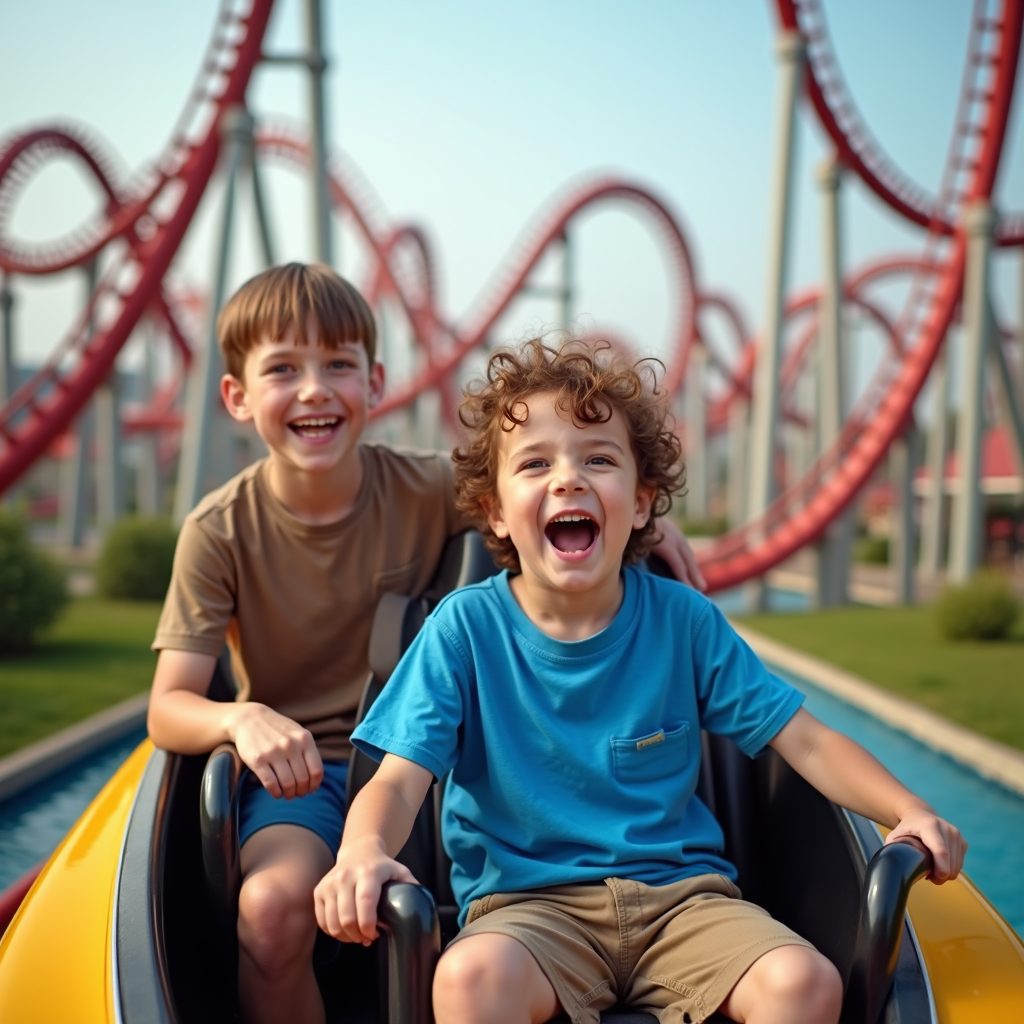

In [5]:
share_bg = False

pipe_kwargs = dict(
    height=height,
    width=width,
    use_interpolate=use_interpolate,
    share_bg=share_bg
)

id_prompt = prompts[0]
frm_prompts = prompts[1:]

print("#" * 50)
print("Generating ID image ...")
num_objects, object_token_ranges = object_info_list[0]
set_text_len(pipe, bg_lens[0], real_lens[0], num_objects=num_objects, object_token_ranges=object_token_ranges)
id_images, id_spatial_kwargs = pipe(
    id_prompt, is_id=True, generator=torch.Generator("cpu").manual_seed(seed), **pipe_kwargs)

if save_intermediate_results:
    cache_payload = dict(
        meta=dict(
            bg_prompts=bg_prompts,
            fg_prompt=fg_prompt,
            act_prompts=act_prompts,
            seed=seed,
            height=height,
            width=width,
            init_mode=init_mode,
        ),
        id=dict(
            prompt=id_prompt,
            bg_len=bg_lens[0],
            real_len=real_lens[0],
            image=np.array(id_images[0]),
            mask=id_spatial_kwargs["curr_fg_mask"][0].cpu().numpy(),
        ),
        frames=[],
    )

id_images[0]

Found 2 object masks


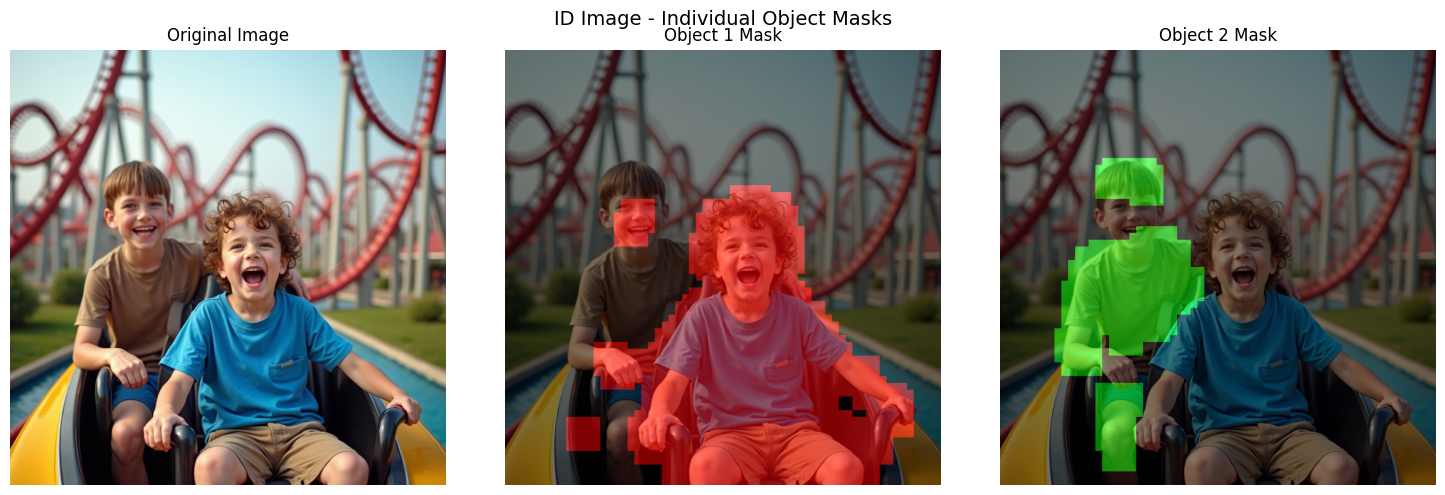

In [6]:
# Visualize individual object masks for ID image
import matplotlib.pyplot as plt
import numpy as np

def visualize_object_masks(image, object_masks, title="Object Masks"):
    """可视化每个对象的独立mask"""
    if object_masks is None or len(object_masks) == 0:
        print("No object masks available")
        return
    
    num_objects = len(object_masks)
    fig, axes = plt.subplots(1, num_objects + 1, figsize=(5 * (num_objects + 1), 5))
    
    # 显示原图
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    # 为每个对象分配不同颜色
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255)]
    
    # 显示每个对象的mask
    for obj_idx, obj_mask in enumerate(object_masks):
        # 处理mask维度
        if len(obj_mask.shape) == 3:  # [B, H, W]
            mask = obj_mask[0].cpu().numpy()
        else:  # [H, W]
            mask = obj_mask.cpu().numpy() if hasattr(obj_mask, 'cpu') else obj_mask
        
        # 创建带颜色的mask overlay
        img_array = np.array(image).astype(np.float32) * 0.5
        mask_resized = Image.fromarray((mask * 255).astype(np.uint8)).resize(image.size, Image.NEAREST)
        mask_resized = np.array(mask_resized)
        mask_resized = mask_resized[:, :, None] / 255.0
        
        color = np.array(colors[obj_idx % len(colors)], dtype=np.float32).reshape(1, 1, -1)
        mask_resized_color = mask_resized * color
        img_array = img_array + mask_resized_color * 0.5
        img_array = np.clip(img_array, 0, 255).astype(np.uint8)
        
        axes[obj_idx + 1].imshow(img_array)
        axes[obj_idx + 1].set_title(f"Object {obj_idx + 1} Mask")
        axes[obj_idx + 1].axis('off')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# 检查是否有 id_object_masks
if "id_object_masks" in id_spatial_kwargs:
    print(f"Found {len(id_spatial_kwargs['id_object_masks'])} object masks")
    visualize_object_masks(
        id_images[0], 
        id_spatial_kwargs["id_object_masks"],
        title="ID Image - Individual Object Masks"
    )
else:
    print("No id_object_masks found. Using combined mask.")
    # 如果没有对象masks，显示合并的mask
    overlay_mask_on_image(id_images[0], id_spatial_kwargs["curr_fg_mask"][0].cpu().numpy(), (255, 0, 0))


## Mask visualization

Here is an additional visualization that demonstrates the character masks automatically extracted by the model.

We performed additional post-processing after extracting the masks: a 3×3 kernel erosion followed by a 5×5 kernel dilation. The use of a larger dilation kernel helps ensure that the mask captures as much of the foreground content as possible.

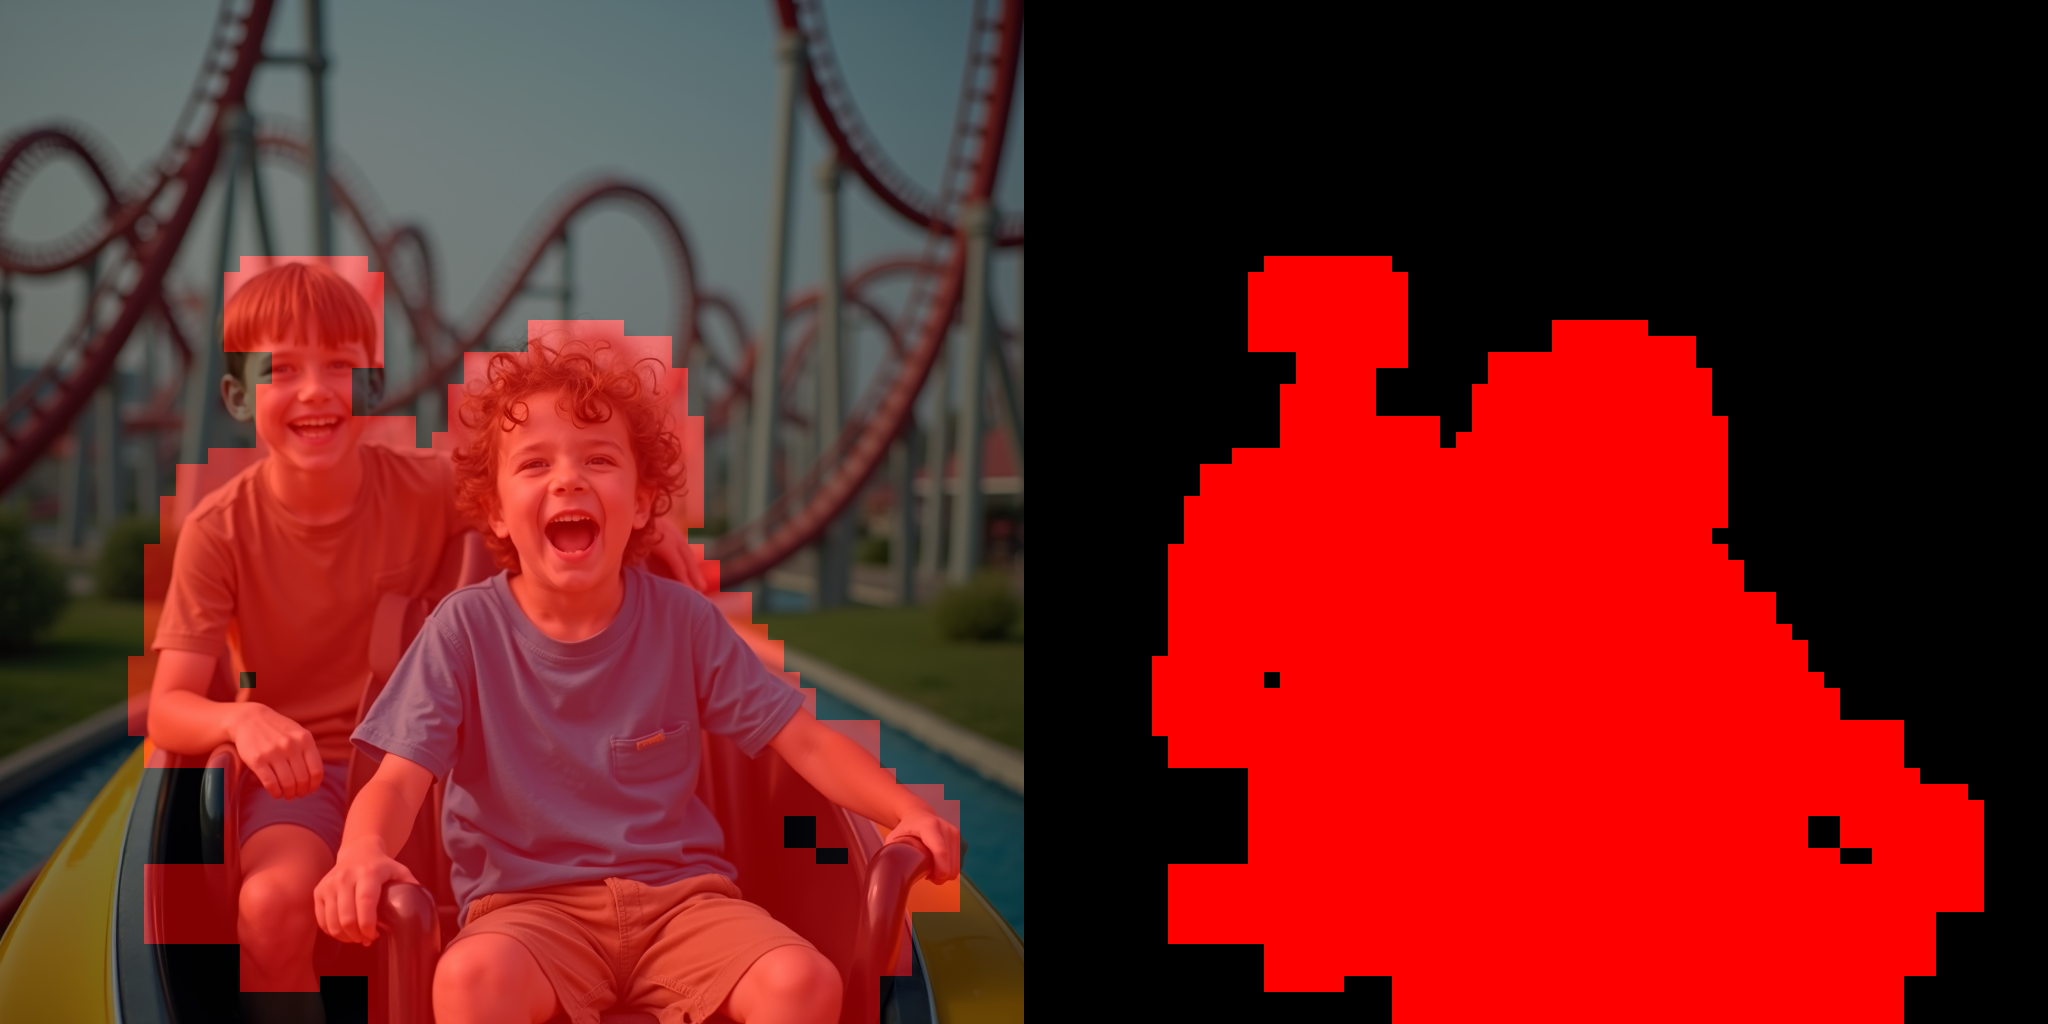

In [7]:
def overlay_mask_on_image(image, mask, color):
    img_array = np.array(image).astype(np.float32) * 0.5
    mask_zero = np.zeros_like(img_array)

    mask_resized = Image.fromarray(mask.astype(np.uint8)).resize(image.size, Image.NEAREST)
    mask_resized = np.array(mask_resized)[:, :, None]
    color = np.array(color, dtype=np.float32).reshape(1, 1, -1)
    mask_resized_color = mask_resized * color
    img_array = img_array + mask_resized_color * 0.5
    mask_zero = mask_zero + mask_resized_color
    out_img = np.concatenate([img_array, mask_zero], axis=1)
    out_img[out_img > 255] = 255
    out_img = out_img.astype(np.uint8)
    return Image.fromarray(out_img)

overlay_mask_on_image(id_images[0], id_spatial_kwargs["curr_fg_mask"][0].cpu().numpy(), (255, 0, 0))

## Frame images generation

The generation process for each frame image consists of two stages: a 10-step "pre-run" followed by the actual generation. The pre-run is used to obtain the mask and point matching results for the current image.

In [ ]:
spatial_kwargs = dict(id_fg_mask=id_spatial_kwargs["curr_fg_mask"], id_bg_mask=~id_spatial_kwargs["curr_fg_mask"])
# 如果是多对象模式，传递 id_object_masks
if "id_object_masks" in id_spatial_kwargs:
    spatial_kwargs["id_object_masks"] = id_spatial_kwargs["id_object_masks"]
    print(f"Multi-object mode: {len(id_spatial_kwargs['id_object_masks'])} objects detected for point matching")

print("#" * 50)
print("Generating frame images ...")
all_images = []
for ind, prompt in enumerate(frm_prompts):
    num_objects, object_token_ranges = object_info_list[1:][ind]
    set_text_len(pipe, bg_lens[1:][ind], real_lens[1:][ind], num_objects=num_objects, object_token_ranges=object_token_ranges)
    _, spatial_kwargs = pipe(
        prompt, is_pre_run=True, generator=torch.Generator("cpu").manual_seed(seed), spatial_kwargs=spatial_kwargs, **pipe_kwargs)
    images, spatial_kwargs = pipe(
        prompt, generator=torch.Generator("cpu").manual_seed(seed), spatial_kwargs=spatial_kwargs, **pipe_kwargs)
    all_images.append(np.array(images[0]))

    if save_intermediate_results and cache_payload is not None:
        frame_entry = dict(
            index=ind,
            prompt=prompt,
            bg_len=bg_lens[1:][ind],
            real_len=real_lens[1:][ind],
            image=np.array(images[0]),
            mask=spatial_kwargs["curr_fg_mask"][0].cpu().numpy(),
        )
        if "argmax_indices" in spatial_kwargs:
            frame_entry["argmax_indices"] = spatial_kwargs["argmax_indices"][0].cpu().numpy()
        if "max_sim" in spatial_kwargs:
            frame_entry["max_sim"] = spatial_kwargs["max_sim"][0].float().cpu().numpy()
        cache_payload["frames"].append(frame_entry)

        if ("argmax_indices" in spatial_kwargs) and ("max_sim" in spatial_kwargs):
            npz_path = os.path.join(point_match_save_dir, f"frame_{ind:02d}.npz")
            save_point_match_package(
                npz_path,
                id_images[0],
                images[0],
                id_spatial_kwargs["curr_fg_mask"][0],
                spatial_kwargs["curr_fg_mask"][0],
                spatial_kwargs["argmax_indices"][0],
                spatial_kwargs["max_sim"][0].float(),
            )

import matplotlib.pyplot as plt
all_images = np.hstack(all_images)
display(Image.fromarray(all_images))

if save_intermediate_results and cache_payload is not None:
    torch.save(cache_payload, cache_path)
    print(f"Intermediate data saved to {cache_path}")

Multi-object mode: 2 objects detected for point matching
##################################################
Generating frame images ...
38 layers' background and real text length have been reset to 14 and 67.
Multi-object mode: 2 objects detected.


  0%|          | 0/50 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 23.88 GiB. GPU 